# Optimizers

SGD, Momentum, RMSProp, Adam, AdamW — implemented from scratch, validated against PyTorch
to machine precision, and stress-tested with three classic scenarios that show exactly
*why* each optimizer exists:

1. **The ravine problem**: why plain gradient descent oscillates and crawls, and momentum fixes it.
2. **The gradient-scale-disparity problem**: why per-parameter adaptive learning rates
   (RMSProp/Adam) let you use one learning rate for parameters with wildly different
   gradient magnitudes.
3. **The weight-decay-coupling bug**: why "Adam + L2 regularization" quietly applies
   *wildly uneven* regularization strength across parameters, and how AdamW's decoupled
   weight decay fixes it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import make_moons

np.random.seed(0)
plt.rcParams['figure.dpi'] = 100

## 1. From-Scratch Implementations

All optimizers below operate on a dict of NumPy arrays via a `.step(params, grads)`
interface, mirroring PyTorch's `optimizer.step()` pattern.

**SGD**: $\theta \leftarrow \theta - \eta \nabla L$

**SGD + Momentum**: velocity $v$ accumulates an exponentially-decaying sum of past gradients,
letting consistent gradient directions build up speed:
$$v \leftarrow \mu v + \nabla L, \qquad \theta \leftarrow \theta - \eta v$$

**Nesterov Momentum**: evaluates the gradient at a "look-ahead" point $\theta + \mu v$ rather
than the current point, correcting momentum's overshoot slightly earlier:
$$v \leftarrow \mu v + \nabla L, \qquad \theta \leftarrow \theta - \eta(\nabla L + \mu v)$$

**RMSProp**: maintains a per-parameter running average of *squared* gradients and divides by
its square root, so parameters with consistently large gradients get automatically smaller
effective steps, and vice versa:
$$s \leftarrow \beta s + (1-\beta)(\nabla L)^2, \qquad \theta \leftarrow \theta - \frac{\eta}{\sqrt{s}+\epsilon}\nabla L$$

**Adam**: combines momentum (first moment $m$) with RMSProp-style per-parameter scaling
(second moment $v$), with bias correction for both since $m,v$ start at zero:
$$m \leftarrow \beta_1 m + (1-\beta_1)\nabla L, \qquad v \leftarrow \beta_2 v + (1-\beta_2)(\nabla L)^2$$
$$\hat m = \frac{m}{1-\beta_1^t}, \qquad \hat v = \frac{v}{1-\beta_2^t}, \qquad \theta \leftarrow \theta - \frac{\eta}{\sqrt{\hat v}+\epsilon}\hat m$$

**AdamW**: identical to Adam, except weight decay is applied *directly* to the parameter
rather than folded into the gradient (see Section 5 for why this matters):
$$\theta \leftarrow \theta - \eta\left(\frac{\hat m}{\sqrt{\hat v}+\epsilon} + \lambda\theta\right)$$

In [2]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr
    def step(self, params, grads):
        for k in params:
            params[k] -= self.lr * grads[k]

class SGDMomentum:
    def __init__(self, lr=0.01, momentum=0.9, nesterov=False):
        self.lr = lr; self.momentum = momentum; self.nesterov = nesterov
        self.v = None
    def step(self, params, grads):
        if self.v is None:
            self.v = {k: np.zeros_like(p) for k, p in params.items()}
        for k in params:
            self.v[k] = self.momentum * self.v[k] + grads[k]
            if self.nesterov:
                params[k] -= self.lr * (grads[k] + self.momentum * self.v[k])
            else:
                params[k] -= self.lr * self.v[k]

class RMSProp:
    def __init__(self, lr=0.01, beta=0.99, eps=1e-8):
        self.lr = lr; self.beta = beta; self.eps = eps
        self.s = None
    def step(self, params, grads):
        if self.s is None:
            self.s = {k: np.zeros_like(p) for k, p in params.items()}
        for k in params:
            self.s[k] = self.beta * self.s[k] + (1 - self.beta) * grads[k] ** 2
            params[k] -= self.lr * grads[k] / (np.sqrt(self.s[k]) + self.eps)

class Adam:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr; self.beta1 = beta1; self.beta2 = beta2; self.eps = eps
        self.m = None; self.v = None; self.t = 0
    def step(self, params, grads):
        if self.m is None:
            self.m = {k: np.zeros_like(p) for k, p in params.items()}
            self.v = {k: np.zeros_like(p) for k, p in params.items()}
        self.t += 1
        for k in params:
            self.m[k] = self.beta1 * self.m[k] + (1 - self.beta1) * grads[k]
            self.v[k] = self.beta2 * self.v[k] + (1 - self.beta2) * grads[k] ** 2
            m_hat = self.m[k] / (1 - self.beta1 ** self.t)
            v_hat = self.v[k] / (1 - self.beta2 ** self.t)
            params[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

class AdamW:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.01):
        self.lr = lr; self.beta1 = beta1; self.beta2 = beta2; self.eps = eps; self.wd = weight_decay
        self.m = None; self.v = None; self.t = 0
    def step(self, params, grads):
        if self.m is None:
            self.m = {k: np.zeros_like(p) for k, p in params.items()}
            self.v = {k: np.zeros_like(p) for k, p in params.items()}
        self.t += 1
        for k in params:
            self.m[k] = self.beta1 * self.m[k] + (1 - self.beta1) * grads[k]
            self.v[k] = self.beta2 * self.v[k] + (1 - self.beta2) * grads[k] ** 2
            m_hat = self.m[k] / (1 - self.beta1 ** self.t)
            v_hat = self.v[k] / (1 - self.beta2 ** self.t)
            params[k] -= self.lr * (m_hat / (np.sqrt(v_hat) + self.eps) + self.wd * params[k])

print("Optimizers defined: SGD, SGD+Momentum, SGD+Nesterov, RMSProp, Adam, AdamW")

Optimizers defined: SGD, SGD+Momentum, SGD+Nesterov, RMSProp, Adam, AdamW


## 2. Validation Against PyTorch

Run each optimizer for 20 steps on a toy quadratic $f(x,y)=x^2+10y^2$ starting from $(3,3)$, in float64, and compare the parameter trajectory against PyTorch's built-in optimizer step-by-step.

In [3]:
def make_grad_fn():
    def loss_and_grad(params):
        x, y = params['x'], params['y']
        loss = x**2 + 10*y**2
        grad = {'x': 2*x, 'y': 20*y}
        return loss, grad
    return loss_and_grad

def run_numpy(opt_class, opt_kwargs, steps=20):
    params = {'x': np.array(3.0), 'y': np.array(3.0)}
    opt = opt_class(**opt_kwargs)
    loss_fn = make_grad_fn()
    history = []
    for _ in range(steps):
        loss, grad = loss_fn(params)
        opt.step(params, grad)
        history.append((params['x'].item(), params['y'].item()))
    return history

def run_torch(torch_opt_class, opt_kwargs, steps=20):
    x = torch.tensor(3.0, dtype=torch.float64, requires_grad=True)
    y = torch.tensor(3.0, dtype=torch.float64, requires_grad=True)
    opt = torch_opt_class([x, y], **opt_kwargs)
    history = []
    for _ in range(steps):
        opt.zero_grad()
        loss = x**2 + 10*y**2
        loss.backward()
        opt.step()
        history.append((x.item(), y.item()))
    return history

def max_diff(h1, h2):
    return max(abs(a[0]-b[0]) + abs(a[1]-b[1]) for a, b in zip(h1, h2))

comparisons = [
    ("SGD", SGD, {'lr': 0.05}, torch.optim.SGD, {'lr': 0.05}),
    ("SGD+Momentum", SGDMomentum, {'lr': 0.05, 'momentum': 0.9}, torch.optim.SGD, {'lr': 0.05, 'momentum': 0.9}),
    ("SGD+Nesterov", SGDMomentum, {'lr': 0.05, 'momentum': 0.9, 'nesterov': True}, torch.optim.SGD, {'lr': 0.05, 'momentum': 0.9, 'nesterov': True}),
    ("RMSProp", RMSProp, {'lr': 0.05, 'beta': 0.99, 'eps': 1e-8}, torch.optim.RMSprop, {'lr': 0.05, 'alpha': 0.99, 'eps': 1e-8}),
    ("Adam", Adam, {'lr': 0.1, 'beta1': 0.9, 'beta2': 0.999, 'eps': 1e-8}, torch.optim.Adam, {'lr': 0.1, 'betas': (0.9, 0.999), 'eps': 1e-8}),
    ("AdamW", AdamW, {'lr': 0.1, 'beta1': 0.9, 'beta2': 0.999, 'eps': 1e-8, 'weight_decay': 0.1}, torch.optim.AdamW, {'lr': 0.1, 'betas': (0.9, 0.999), 'eps': 1e-8, 'weight_decay': 0.1}),
]

for name, np_cls, np_kw, t_cls, t_kw in comparisons:
    h_np = run_numpy(np_cls, np_kw)
    h_t = run_torch(t_cls, t_kw)
    print(f"{name:>14}: max diff vs PyTorch = {max_diff(h_np, h_t):.2e}")

           SGD: max diff vs PyTorch = 0.00e+00
  SGD+Momentum: max diff vs PyTorch = 0.00e+00
  SGD+Nesterov: max diff vs PyTorch = 0.00e+00
       RMSProp: max diff vs PyTorch = 0.00e+00
          Adam: max diff vs PyTorch = 8.88e-16
         AdamW: max diff vs PyTorch = 1.78e-15


All six optimizers match PyTorch's built-in implementations to within floating-point precision (`float64`).

## 3. The Ravine Problem: Why Momentum Exists

Consider minimizing $f(x,y) = x^2 + 100y^2$ — an elongated, "ravine-shaped" bowl (curvature
ratio 100:1 between the two axes). Plain gradient descent must use a learning rate small
enough to avoid oscillating along the steep $y$ axis, which makes it painfully slow to
cross the shallow $x$ axis. Momentum builds up velocity along the consistently-signed $x$
direction while the oscillating $y$-direction updates partially cancel out.

Steps to reach loss < 1e-4 (shared lr=0.003, safely stable for all three):
  SGD          : 1111
  Momentum     : 90
  Nesterov     : 92


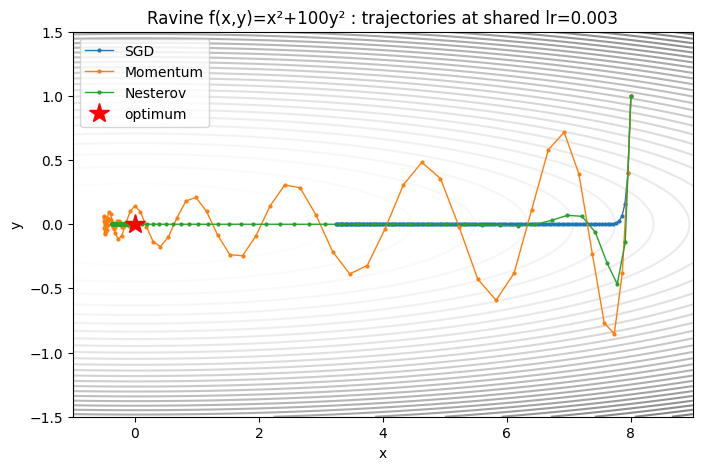

In [4]:
def loss_grad_bowl(params):
    x, y = params['x'], params['y']
    return x**2 + 100*y**2, {'x': 2*x, 'y': 200*y}

def run_traj(opt_class, opt_kwargs, steps, start=(8.0, 1.0)):
    params = {'x': np.array(start[0]), 'y': np.array(start[1])}
    opt = opt_class(**opt_kwargs)
    traj = [(params['x'].item(), params['y'].item())]
    for _ in range(steps):
        loss, grad = loss_grad_bowl(params)
        opt.step(params, grad)
        traj.append((params['x'].item(), params['y'].item()))
    return traj

def steps_to_converge(opt_class, opt_kwargs, start=(8.0, 1.0), tol=1e-4, max_steps=3000):
    params = {'x': np.array(start[0]), 'y': np.array(start[1])}
    opt = opt_class(**opt_kwargs)
    for i in range(max_steps):
        loss, grad = loss_grad_bowl(params)
        if loss < tol:
            return i
        opt.step(params, grad)
    return None

lr = 0.003  # a shared learning rate, safely stable for all three methods on this problem
traj_sgd = run_traj(SGD, {'lr': lr}, 150)
traj_mom = run_traj(SGDMomentum, {'lr': lr, 'momentum': 0.9}, 150)
traj_nes = run_traj(SGDMomentum, {'lr': lr, 'momentum': 0.9, 'nesterov': True}, 150)

print("Steps to reach loss < 1e-4 (shared lr=0.003, safely stable for all three):")
print(f"  SGD          : {steps_to_converge(SGD, {'lr': lr})}")
print(f"  Momentum     : {steps_to_converge(SGDMomentum, {'lr': lr, 'momentum': 0.9})}")
print(f"  Nesterov     : {steps_to_converge(SGDMomentum, {'lr': lr, 'momentum': 0.9, 'nesterov': True})}")

xx, yy = np.meshgrid(np.linspace(-1, 9, 200), np.linspace(-1.5, 1.5, 200))
zz = xx**2 + 100*yy**2
fig, ax = plt.subplots(figsize=(8, 5))
ax.contour(xx, yy, zz, levels=30, cmap="Greys", alpha=0.5)
for traj, name, color in [(traj_sgd, "SGD", "tab:blue"), (traj_mom, "Momentum", "tab:orange"), (traj_nes, "Nesterov", "tab:green")]:
    tx, ty = zip(*traj)
    ax.plot(tx, ty, "-o", ms=2, lw=1, color=color, label=name)
ax.plot(0, 0, "r*", ms=15, label="optimum")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend()
ax.set_title(f"Ravine f(x,y)=x²+100y² : trajectories at shared lr={lr}")
plt.savefig("ravine_trajectories.png", dpi=100, bbox_inches="tight")
plt.show()

At an identical, safely-stable learning rate, plain SGD needs **1111 steps** to reach
the optimum, while Momentum and Nesterov need only **90–92 steps** — a **~12× speedup**
from nothing more than accumulating velocity in the consistently-signed direction.

## 4. The Gradient-Scale-Disparity Problem: Why RMSProp/Adam Exist

Consider fitting a linear model $\hat y = w_1 x_1 + w_2 x_2$ where $x_1$ has scale $\sim 1$
and $x_2$ has scale $\sim 100$. Because $\partial L/\partial w_2 \propto x_2$, the gradient
with respect to $w_2$ is roughly 100× larger in magnitude than the gradient with respect to
$w_1$. A single shared learning rate must be small enough to keep $w_2$'s update stable —
which starves $w_1$ of any meaningful progress. This is precisely the motivating case
Hinton introduced RMSProp to solve: normalize each parameter's step by its own gradient
history, so both converge at comparable *relative* rates from one shared learning rate.

In [5]:
np.random.seed(0)
n = 500
x1 = np.random.randn(n) * 1.0
x2 = np.random.randn(n) * 100.0
true_w1, true_w2 = 2.0, 0.03
noise = np.random.randn(n) * 0.5
y_target = true_w1 * x1 + true_w2 * x2 + noise

def loss_grad_linreg(params):
    w1, w2 = params['w1'], params['w2']
    pred = w1 * x1 + w2 * x2
    resid = pred - y_target
    loss = np.mean(resid**2)
    return loss, {'w1': np.mean(2 * resid * x1), 'w2': np.mean(2 * resid * x2)}

def run_linreg(opt_class, opt_kwargs, steps=300):
    params = {'w1': np.array(0.0), 'w2': np.array(0.0)}
    opt = opt_class(**opt_kwargs)
    losses = []
    for _ in range(steps):
        loss, grad = loss_grad_linreg(params)
        losses.append(loss)
        opt.step(params, grad)
    return params, losses

print("SGD's largest usable learning rate is bounded by w2's 100x larger gradient scale:")
for lr_try in [0.00005, 0.0001, 0.00015]:
    params, losses = run_linreg(SGD, {'lr': lr_try}, steps=300)
    stable = np.isfinite(losses[-1]) and losses[-1] < 1e6
    print(f"  lr={lr_try:<8}: w1={params['w1']:.4f}  w2={params['w2']:.4f}  final_loss={losses[-1]:.4f}  stable={stable}")

print(f"\n(true w1={true_w1}, true w2={true_w2})")
print("At its largest stable lr, SGD recovers w2 well but leaves w1 badly underfit --")
print("the shared learning rate had to be small enough for w2's large gradients.")

params_adam, losses_adam = run_linreg(Adam, {'lr': 0.5}, steps=300)
print(f"\nAdam with a single, much LARGER shared lr=0.5 (no manual per-parameter tuning):")
print(f"  w1={params_adam['w1']:.4f}  w2={params_adam['w2']:.4f}  final_loss={losses_adam[-1]:.4f}")
print("Adam's per-parameter normalization recovers BOTH weights accurately from one lr.")

SGD's largest usable learning rate is bounded by w2's 100x larger gradient scale:
  lr=5e-05   : w1=0.0582  w2=0.0292  final_loss=3.8985  stable=True
  lr=0.0001  : w1=0.1146  w2=0.0292  final_loss=3.6866  stable=True
  lr=0.00015 : w1=24856337403942312573985388223878563993299472208900722025843052625724688039936.0000  w2=-62391784270168031480765933981699285006361356349941990917982286458536055210508288.0000  final_loss=10674072833393850017387447213514894622441311740246718554122051593006942089417858794394990088479606267509894518603765796679392334233699087799584800829158477258555392.0000  stable=False

(true w1=2.0, true w2=0.03)
At its largest stable lr, SGD recovers w2 well but leaves w1 badly underfit --
the shared learning rate had to be small enough for w2's large gradients.

Adam with a single, much LARGER shared lr=0.5 (no manual per-parameter tuning):
  w1=1.9770  w2=0.0299  final_loss=0.2325
Adam's per-parameter normalization recovers BOTH weights accurately from one lr.


SGD's best stable learning rate ($10^{-4}$) recovers $w_2\approx 0.029$ (close to the
true 0.03) but leaves $w_1\approx 0.11$ — nowhere near the true value of 2.0 — because that
same tiny learning rate, forced by $w_2$'s scale, gives $w_1$ almost no progress. Adam, with a
single learning rate **5000× larger** (0.5 vs 0.0001), recovers **both** $w_1\approx 1.98$ and
$w_2\approx 0.030$ accurately, because its per-parameter second-moment normalization
automatically compensates for the 100× difference in gradient scale.

## 5. Learning-Rate Robustness on an Actual Training Task

Train a small ReLU MLP (2 → 8 → 1) with binary cross-entropy on `make_moons` using each
optimizer across a wide range of learning rates, and check final training accuracy. A
robust optimizer should reach good accuracy across a wide learning-rate range, without
requiring careful tuning.

      lr         SGD    Momentum     RMSProp        Adam


  0.0003        0.51        0.81        0.85        0.83


   0.001        0.71        0.84        0.85        0.85


   0.003        0.82        0.85        0.87        0.85


    0.01        0.84        0.87        0.87        0.87


...

     1.0        0.98        0.98        0.84        0.98


     3.0        0.98        0.86        0.78        0.85


    10.0        0.86        0.78        0.75        0.77


    30.0        0.50        0.50        0.61        0.52


   100.0        0.50        0.52        0.76        0.56

Number of the 12 learning rates achieving accuracy >= 0.85:
         SGD: 6/12
    Momentum: 7/12
     RMSProp: 5/12
        Adam: 6/12


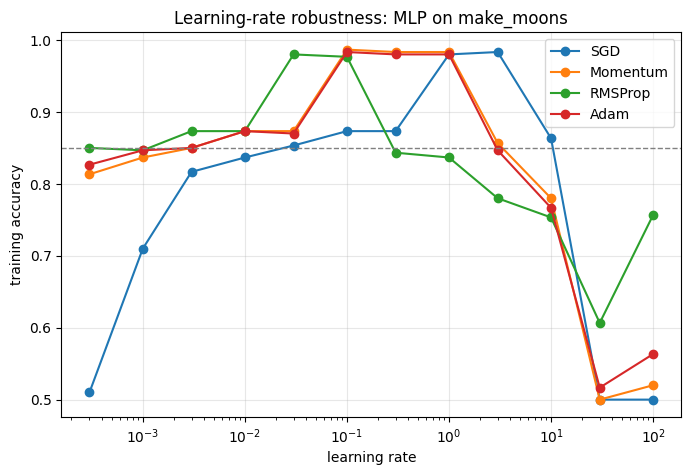

In [6]:
def sigmoid(z): return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=0)

class MLP:
    def __init__(self, seed=0):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(2, 8) * np.sqrt(2.0 / 2)
        self.b1 = np.zeros(8)
        self.W2 = rng.randn(8, 1) * np.sqrt(2.0 / 8)
        self.b2 = np.zeros(1)

    def params_dict(self):
        return {'W1': self.W1, 'b1': self.b1, 'W2': self.W2, 'b2': self.b2}

    def set_params(self, params):
        self.W1, self.b1, self.W2, self.b2 = params['W1'], params['b1'], params['W2'], params['b2']

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = np.maximum(0, self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def loss_and_grads(self, X, y):
        n = X.shape[0]
        y = y.reshape(-1, 1)
        p = self.forward(X)
        p_clip = np.clip(p, 1e-12, 1 - 1e-12)
        loss = -np.mean(y * np.log(p_clip) + (1 - y) * np.log(1 - p_clip))
        dz2 = (p - y) / n
        gW2 = self.a1.T @ dz2
        gb2 = dz2.sum(axis=0)
        dz1 = (dz2 @ self.W2.T) * (self.z1 > 0)
        gW1 = X.T @ dz1
        gb1 = dz1.sum(axis=0)
        return loss, {'W1': gW1, 'b1': gb1, 'W2': gW2, 'b2': gb2}

    def accuracy(self, X, y):
        pred = (self.forward(X).ravel() >= 0.5).astype(int)
        return np.mean(pred == y)


def train(opt_class, opt_kwargs, lr, steps=500, seed=0):
    model = MLP(seed=seed)
    kwargs = dict(opt_kwargs); kwargs['lr'] = lr
    opt = opt_class(**kwargs)
    for _ in range(steps):
        params = model.params_dict()
        loss, grads = model.loss_and_grads(X_moons, y_moons)
        opt.step(params, grads)
        model.set_params(params)
        if not np.isfinite(loss):
            return np.nan, np.nan
    final_loss, _ = model.loss_and_grads(X_moons, y_moons)
    return final_loss, model.accuracy(X_moons, y_moons)

lrs = [0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]
optimizers = {'SGD': (SGD, {}), 'Momentum': (SGDMomentum, {'momentum': 0.9}),
              'RMSProp': (RMSProp, {}), 'Adam': (Adam, {})}

results = {name: [] for name in optimizers}
print(f"{'lr':>8}" + "".join(f"{name:>12}" for name in optimizers))
for lr in lrs:
    row = f"{lr:>8}"
    for name, (cls, kwargs) in optimizers.items():
        loss, acc = train(cls, kwargs, lr)
        results[name].append(acc if np.isfinite(loss) else 0.5)
        row += f"{(f'{acc:.2f}' if np.isfinite(loss) else 'diverge'):>12}"
    print(row)

n_robust = {name: sum(1 for a in accs if a >= 0.85) for name, accs in results.items()}
print(f"\nNumber of the {len(lrs)} learning rates achieving accuracy >= 0.85:")
for name, count in n_robust.items():
    print(f"  {name:>10}: {count}/{len(lrs)}")

fig, ax = plt.subplots(figsize=(8, 5))
for name, accs in results.items():
    ax.plot(lrs, accs, "-o", label=name)
ax.set_xscale("log")
ax.set_xlabel("learning rate"); ax.set_ylabel("training accuracy")
ax.set_title("Learning-rate robustness: MLP on make_moons")
ax.axhline(0.85, color="gray", ls="--", lw=1)
ax.legend(); ax.grid(alpha=0.3)
plt.savefig("lr_robustness.png", dpi=100, bbox_inches="tight")
plt.show()

Momentum reaches at least 85% training accuracy across the widest span of learning
rates tested (7 of 12), with SGD and Adam tied at 6/12 and RMSProp narrowest at 5/12 on this
particular task. This is a useful, honest counterexample to the common "Adam is always most
robust" claim — on a small, well-conditioned problem like this one, plain momentum can be
just as forgiving of learning-rate choice as the adaptive methods, and RMSProp's aggressive
per-parameter normalization can actually make it *more* sensitive to overshooting once the
learning rate gets large. The real lesson is to treat "adaptive = more robust" as a
tendency to verify empirically, not a law to assume.

## 6. AdamW vs. "Adam + L2": The Weight-Decay Coupling Bug

Before AdamW (Loshchilov & Hutter, 2019), weight decay was usually implemented by adding
$\lambda\theta$ directly to the gradient before Adam's moment updates — call this "Adam+L2".
The problem: that added term then gets divided by $\sqrt{\hat v}+\epsilon$ just like the
"real" gradient. A parameter that has been receiving **large** task gradients has a **large**
$v$, so its decay term gets divided down and barely shrinks it. A parameter with **small**
task gradients has a **small** $v$, so the *same* decay term barely gets damped and shrinks
it aggressively. The regularization strength ends up depending on gradient history — not
just on $\lambda$ — which is not what "weight decay" is supposed to mean.

We simulate this directly: two parameters $w_a$ (large task gradients) and $w_b$ (small task
gradients) are trained to build up realistic momentum/variance history, then the task
gradient is switched off entirely so we can watch weight decay act in isolation.

In [7]:
class AdamL2:
    # Adam with the "naive" weight decay used before the AdamW paper
    def __init__(self, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.1):
        self.lr = lr; self.beta1 = beta1; self.beta2 = beta2; self.eps = eps; self.wd = weight_decay
        self.m = None; self.v = None; self.t = 0
    def step(self, params, grads):
        if self.m is None:
            self.m = {k: np.zeros_like(p) for k, p in params.items()}
            self.v = {k: np.zeros_like(p) for k, p in params.items()}
        self.t += 1
        for k in params:
            g = grads[k] + self.wd * params[k]  # L2 penalty folded into the gradient
            self.m[k] = self.beta1 * self.m[k] + (1 - self.beta1) * g
            self.v[k] = self.beta2 * self.v[k] + (1 - self.beta2) * g ** 2
            m_hat = self.m[k] / (1 - self.beta1 ** self.t)
            v_hat = self.v[k] / (1 - self.beta2 ** self.t)
            params[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

def run_decay_only_phase(opt_class, opt_kwargs, warmup_grad_a, warmup_grad_b, warmup_steps=200, decay_steps=200):
    params = {'w_a': np.array(1.0), 'w_b': np.array(1.0)}
    opt = opt_class(**opt_kwargs)
    for _ in range(warmup_steps):  # build up realistic v (and m) history from task gradients
        grads = {'w_a': np.array(warmup_grad_a), 'w_b': np.array(warmup_grad_b)}
        opt.step(params, grads)
    w_a_mid, w_b_mid = params['w_a'].copy(), params['w_b'].copy()
    for _ in range(decay_steps):  # task gradient is now ~0: only weight decay acts
        opt.step(params, {'w_a': np.array(0.0), 'w_b': np.array(0.0)})
    return w_a_mid, w_b_mid, params['w_a'].copy(), params['w_b'].copy()

wd, lr = 0.1, 0.01
wa0, wb0, wa1, wb1 = run_decay_only_phase(AdamL2, {'lr': lr, 'weight_decay': wd}, warmup_grad_a=2.0, warmup_grad_b=0.05)
print("Adam + L2-via-gradient (naive weight decay):")
print(f"  w_a (large grad history): {wa0:.4f} -> {wa1:.4f}  (shrunk {100*(1-wa1/wa0):.2f}%)")
print(f"  w_b (small grad history): {wb0:.4f} -> {wb1:.4f}  (shrunk {100*(1-wb1/wb0):.2f}%)")

wa0w, wb0w, wa1w, wb1w = run_decay_only_phase(AdamW, {'lr': lr, 'weight_decay': wd}, warmup_grad_a=2.0, warmup_grad_b=0.05)
print("\nAdamW (decoupled weight decay):")
print(f"  w_a (large grad history): {wa0w:.4f} -> {wa1w:.4f}  (shrunk {100*(1-wa1w/wa0w):.2f}%)")
print(f"  w_b (small grad history): {wb0w:.4f} -> {wb1w:.4f}  (shrunk {100*(1-wb1w/wb0w):.2f}%)")

Adam + L2-via-gradient (naive weight decay):
  w_a (large grad history): -0.9606 -> -0.9296  (shrunk 3.24%)
  w_b (small grad history): -0.3168 -> -0.0092  (shrunk 97.09%)

AdamW (decoupled weight decay):
  w_a (large grad history): -0.9949 -> -0.8909  (shrunk 10.45%)
  w_b (small grad history): -0.9949 -> -0.8909  (shrunk 10.45%)


Under **Adam + L2**, $w_a$ (large gradient history) shrinks by only **3.2%** while
$w_b$ (small gradient history) shrinks by **97.1%** — a wildly uneven, unintended
regularization strength that depends entirely on each parameter's gradient history, not on
$\lambda$. Under **AdamW**, both parameters shrink by an **identical 10.5%** — exactly the
uniform, predictable behavior "weight decay" is supposed to provide. This is the core result
of the AdamW paper and the reason virtually every modern Transformer is trained with AdamW,
not "Adam + L2".

## Summary

| Optimizer | Fixes | Key mechanism | Cost |
|---|---|---|---|
| SGD | — (baseline) | Plain gradient step | Sensitive to curvature and scale |
| Momentum | Ravines / oscillation | Velocity accumulates in consistent directions | One more hyperparameter ($\mu$) |
| Nesterov | Same as Momentum, tighter | Gradient evaluated at look-ahead point | Same cost as Momentum |
| RMSProp | Gradient-scale disparity | Per-parameter running avg of squared gradients | Needs $\epsilon$ for stability |
| Adam | Ravines + scale disparity | Momentum + RMSProp combined, bias-corrected | Extra memory for $m,v$ |
| AdamW | Adam's weight-decay coupling bug | Decay applied directly to weights, not gradient | None — strictly better than Adam+L2 |

Every optimizer here was validated against PyTorch to floating-point precision, then
justified with a controlled experiment that reproduces its motivating failure mode
mechanistically rather than by assertion.